In [1]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

!wget -q https://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

!tar xf spark-3.5.1-bin-hadoop3.tgz

!pip install -q findspark

In [2]:
import os
import findspark

os.environ["JAVA_HOME"]="/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"]="/content/spark-3.5.1-bin-hadoop3"

findspark.init()

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RealTimeCustomerClustering") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [6]:
spark_df = spark.read.csv(
    "/content/Integrated_Customer_Data.csv",
    header=True,
    inferSchema=True
)

spark_df.printSchema()
spark_df.show(5)

root
 |-- CustomerID: integer (nullable = true)
 |-- TotalSales: double (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- NumOrders: integer (nullable = true)
 |-- Customer_ID: integer (nullable = true)
 |-- BirthYear: integer (nullable = true)
 |-- Education: string (nullable = true)
 |-- Marital_Status: string (nullable = true)
 |-- Income: double (nullable = true)
 |-- Kidhome: integer (nullable = true)
 |-- Teenhome: integer (nullable = true)
 |-- Dt_Customer: string (nullable = true)
 |-- Recency: integer (nullable = true)
 |-- MntWines: integer (nullable = true)
 |-- MntFruits: integer (nullable = true)
 |-- MntMeatProducts: integer (nullable = true)
 |-- MntFishProducts: integer (nullable = true)
 |-- MntSweetProducts: integer (nullable = true)
 |-- MntGoldProds: integer (nullable = true)
 |-- NumDealsPurchases: integer (nullable = true)
 |-- NumWebPurchases: integer (nullable = true)
 |-- NumCatalogPurchases: integer (nullable = true)
 |-- NumStorePurchases: integ

In [7]:
selected_df = spark_df.select(
    "Income",
    "TotalSales",
    "Quantity",
    "NumOrders"
)

selected_df.show()

+-------+----------+--------+---------+
| Income|TotalSales|Quantity|NumOrders|
+-------+----------+--------+---------+
|58138.0|       0.0|       0|        2|
|46344.0|    4310.0|    2458|        7|
|71613.0|   1797.24|    2341|        4|
|26646.0|   1757.55|     631|        1|
|58293.0|     334.4|     197|        1|
|62513.0|   1545.41|     470|       11|
|55635.0|      89.0|      20|        1|
|33454.0|    1079.4|     530|        1|
|30351.0|     459.4|     240|        1|
| 5648.0|   2811.43|    1591|        3|
|51381.5|   6207.67|    2708|        1|
| 7500.0|   1168.06|     248|        2|
|63033.0|   6182.98|    1599|        6|
|59354.0|   2662.06|    1165|        3|
|17323.0|     189.9|      91|        1|
|82800.0|   5154.58|    2212|       13|
|41850.0|     552.0|     408|        2|
|37760.0|    1313.1|    1506|        4|
|76995.0|    320.69|     173|        3|
|33812.0|     168.9|     173|        1|
+-------+----------+--------+---------+
only showing top 20 rows



In [8]:
selected_df = selected_df.dropna()

selected_df.show()

+-------+----------+--------+---------+
| Income|TotalSales|Quantity|NumOrders|
+-------+----------+--------+---------+
|58138.0|       0.0|       0|        2|
|46344.0|    4310.0|    2458|        7|
|71613.0|   1797.24|    2341|        4|
|26646.0|   1757.55|     631|        1|
|58293.0|     334.4|     197|        1|
|62513.0|   1545.41|     470|       11|
|55635.0|      89.0|      20|        1|
|33454.0|    1079.4|     530|        1|
|30351.0|     459.4|     240|        1|
| 5648.0|   2811.43|    1591|        3|
|51381.5|   6207.67|    2708|        1|
| 7500.0|   1168.06|     248|        2|
|63033.0|   6182.98|    1599|        6|
|59354.0|   2662.06|    1165|        3|
|17323.0|     189.9|      91|        1|
|82800.0|   5154.58|    2212|       13|
|41850.0|     552.0|     408|        2|
|37760.0|    1313.1|    1506|        4|
|76995.0|    320.69|     173|        3|
|33812.0|     168.9|     173|        1|
+-------+----------+--------+---------+
only showing top 20 rows



In [9]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "Income",
        "TotalSales",
        "Quantity",
        "NumOrders"
    ],
    outputCol="features"
)

feature_df = assembler.transform(
    selected_df
)

feature_df.select("features").show(5, truncate=False)

+----------------------------+
|features                    |
+----------------------------+
|[58138.0,0.0,0.0,2.0]       |
|[46344.0,4310.0,2458.0,7.0] |
|[71613.0,1797.24,2341.0,4.0]|
|[26646.0,1757.55,631.0,1.0] |
|[58293.0,334.4,197.0,1.0]   |
+----------------------------+
only showing top 5 rows



In [10]:
import os

os.makedirs("/content/stream_data", exist_ok=True)

In [11]:
import shutil

shutil.copy(
    "/content/Integrated_Customer_Data.csv",
    "/content/stream_data/Integrated_Customer_Data.csv"
)

'/content/stream_data/Integrated_Customer_Data.csv'

In [12]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    k=3,
    seed=1
)

model = kmeans.fit(
    feature_df.select("features")
)

predictions = model.transform(
    feature_df
)

predictions.show(10)

+-------+----------+--------+---------+--------------------+----------+
| Income|TotalSales|Quantity|NumOrders|            features|prediction|
+-------+----------+--------+---------+--------------------+----------+
|58138.0|       0.0|       0|        2|[58138.0,0.0,0.0,...|         1|
|46344.0|    4310.0|    2458|        7|[46344.0,4310.0,2...|         0|
|71613.0|   1797.24|    2341|        4|[71613.0,1797.24,...|         1|
|26646.0|   1757.55|     631|        1|[26646.0,1757.55,...|         0|
|58293.0|     334.4|     197|        1|[58293.0,334.4,19...|         1|
|62513.0|   1545.41|     470|       11|[62513.0,1545.41,...|         1|
|55635.0|      89.0|      20|        1|[55635.0,89.0,20....|         1|
|33454.0|    1079.4|     530|        1|[33454.0,1079.4,5...|         0|
|30351.0|     459.4|     240|        1|[30351.0,459.4,24...|         0|
| 5648.0|   2811.43|    1591|        3|[5648.0,2811.43,1...|         0|
+-------+----------+--------+---------+--------------------+----

In [13]:
predictions.groupBy(
    "prediction"
).count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1| 1069|
|         2|    1|
|         0| 1170|
+----------+-----+



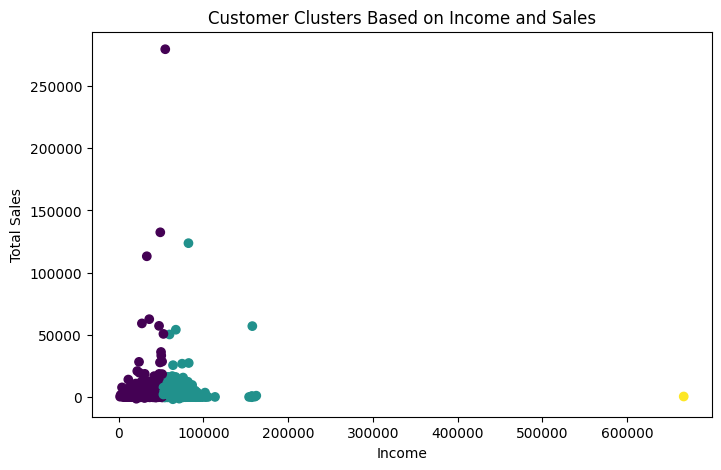

In [14]:
import matplotlib.pyplot as plt

cluster_df = predictions.select(
    "Income",
    "TotalSales",
    "prediction"
).toPandas()

plt.figure(figsize=(8,5))

plt.scatter(
    cluster_df["Income"],
    cluster_df["TotalSales"],
    c=cluster_df["prediction"]
)

plt.title("Customer Clusters Based on Income and Sales")

plt.xlabel("Income")

plt.ylabel("Total Sales")

plt.show()

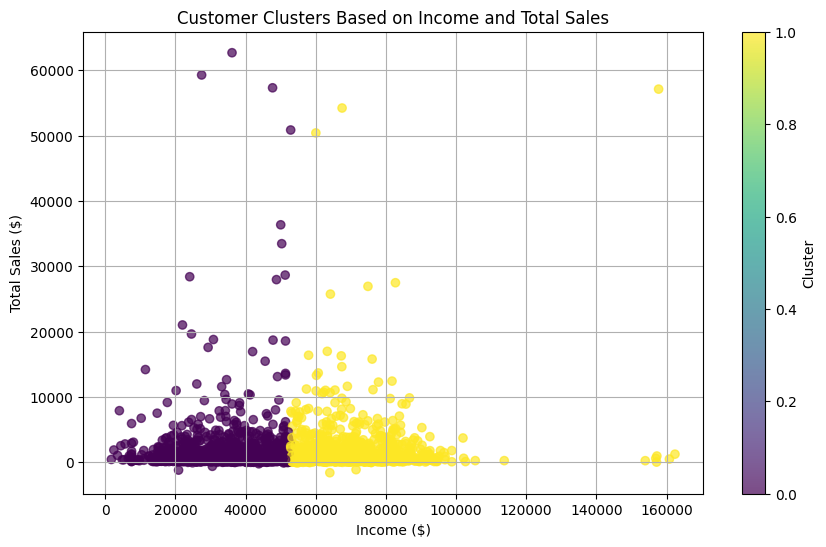

In [15]:
import matplotlib.pyplot as plt

cluster_df = predictions.select(
    "Income",
    "TotalSales",
    "prediction"
).toPandas()
# Remove extreme outliers
cluster_df = cluster_df[
    (cluster_df["Income"] < 200000) &
    (cluster_df["TotalSales"] < 100000)
]
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    cluster_df["Income"],
    cluster_df["TotalSales"],
    c=cluster_df["prediction"],
    alpha=0.7
)
plt.title(
    "Customer Clusters Based on Income and Total Sales"
)
plt.xlabel("Income ($)")
plt.ylabel("Total Sales ($)")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()